In [220]:
%load_ext autoreload
%autoreload 2

import os 
import sys

import numpy as np
import matplotlib.pyplot as plt
import cv2 


root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.transforms_numpy import polar2cartesian, addSpeckleNoise, energyLoss, addBandReflects


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [221]:
# === config ===

SEQ_ID = 1
FRAME_NO = 402

In [222]:
# def sonar_polar_to_cartesian(raw_data, min_range, max_range, fov_deg, output_size_px, clear_background=True):
#     """
#     Transformuje surowe dane sonarowe (polarny) na obraz kartezjański.
    
#     Argumenty:
#     - raw_data: 2D numpy array (bins, beams) - surowe dane z fls/image
#     - min_range: minimalny zasięg sonaru (w metrach)
#     - max_range: maksymalny zasięg sonaru (w metrach)
#     - fov_deg: kąt widzenia sonaru w stopniach (np. 120)
#     - output_size_px: krotka (height, width) rozmiaru obrazu wynikowego
#     - clear_background: czy czyścić tło (poza zasięgiem wiązki) na czarno
    
#     Zwraca:
#     - cartesian_img: 2D numpy array (obraz w układzie kartezjańskim)
#     """
    
#     # 1. Pobieramy wymiary surowych danych
#     # W Stonefish raw_data zazwyczaj ma kształt (liczba_próbek_zasięgu, liczba_wiązek)
#     n_bins, n_beams = raw_data.shape
    
#     out_h, out_w = output_size_px
    
#     # 2. Definiujemy fizyczne wymiary sceny wyjściowej
#     # Zakładamy, że obraz obejmuje obszar:
#     # X (przód): od 0 do max_range
#     # Y (boki): od -max_range do +max_range (żeby zmieścić cały stożek)
    
#     # Tworzymy siatkę współrzędnych pikseli (u, v)
#     u = np.arange(out_w)
#     v = np.arange(out_h)
#     U, V = np.meshgrid(u, v)
    
#     # 3. Transformacja pikseli (u, v) na fizyczne (x, y) w metrach
#     # Układ współrzędnych sonaru: X do przodu, Y w prawo.
#     # Obraz: środek na dole to (x=0, y=0)
    
#     px_resolution = (2 * max_range) / out_w # metry na piksel (szerokość)
    
#     # y_metric: od -max_range (lewo) do +max_range (prawo)
#     y_metric = (U - out_w / 2.0) * px_resolution
    
#     # x_metric: od max_range (góra obrazu) do 0 (dół obrazu)
#     # Odwracamy V, bo w obrazach współrzędna 0 jest na górze
#     x_metric = (out_h - V) * px_resolution 
#     # Uwaga: jeśli chcemy idealne skalowanie 1:1, out_h powinno wynosić out_w / 2
    
#     # 4. Konwersja (x, y) -> (r, theta) (Polar)
#     r_grid = np.sqrt(x_metric**2 + y_metric**2)
#     theta_grid = np.arctan2(y_metric, x_metric) # Wynik w radianach
    
#     # Konwersja FOV na radiany
#     fov_rad = np.deg2rad(fov_deg)
    
#     # 5. Mapowanie (r, theta) na indeksy w tablicy raw_data (bin, beam)
    
#     # A. Indeks promienia (bin)
#     # bin 0 to min_range, bin_max to max_range
#     bin_idx = (r_grid - min_range) / (max_range - min_range) * n_bins
    
#     # B. Indeks kąta (beam)
#     # theta zmienia się od -FOV/2 do +FOV/2
#     # beam 0 to zazwyczaj lewa krawędź (-FOV/2)
#     beam_idx = (theta_grid + (fov_rad / 2.0)) / fov_rad * n_beams
    
#     # 6. Obsługa warunków brzegowych (maskowanie)
#     mask = np.ones_like(r_grid, dtype=bool)
    
#     # Maska: punkt musi być w zasięgu (min < r < max)
#     mask &= (r_grid >= min_range) & (r_grid < max_range)
    
#     # Maska: punkt musi być w kącie widzenia (-FOV/2 < theta < +FOV/2)
#     mask &= (np.abs(theta_grid) <= fov_rad / 2.0)
    
#     # Maska: indeksy tablicy muszą być poprawne
#     mask &= (bin_idx >= 0) & (bin_idx < n_bins - 1)
#     mask &= (beam_idx >= 0) & (beam_idx < n_beams - 1)
    
#     # 7. Pobieranie wartości (Sampling) - Metoda Najbliższego Sąsiada (Nearest Neighbor)
#     # Dla lepszej jakości można tu użyć interpolacji biliniowej
    
#     # Rzutujemy na liczby całkowite
#     bin_idx_int = np.floor(bin_idx).astype(int)
#     beam_idx_int = np.floor(beam_idx).astype(int)
    
#     # Przygotowujemy pusty obraz
#     cartesian_img = np.zeros((out_h, out_w), dtype=raw_data.dtype)
    
#     if not clear_background:
#          cartesian_img[:] = np.min(raw_data) # Wypełnij tłem z danych
         
#     # Wypełniamy wartościami tam, gdzie maska jest True
#     cartesian_img[mask] = raw_data[bin_idx_int[mask], beam_idx_int[mask]]
    
#     return cartesian_img

In [223]:
import numpy as np
import cv2  # Opcjonalne, tylko jeśli potrzebujesz do zapisu/wyświetlania

def sonar_polar_to_cartesian(raw_data, min_range, max_range, fov_deg, output_size_px, reverse_range_mapping=True):
    """
    Transformuje dane sonarowe na kartezjańskie z opcją odwrócenia osi zasięgu.
    
    Argumenty:
    - raw_data: (bins, beams) - surowe dane.
    - reverse_range_mapping: 
        True  -> Wiersz 0 danych to r_max (zewnętrzny łuk), Ostatni wiersz to r_min (źródło).
        False -> Wiersz 0 danych to r_min (źródło), Ostatni wiersz to r_max (zewnętrzny łuk).
    """
    
    n_bins, n_beams = raw_data.shape
    out_h, out_w = output_size_px
    
    # --- 1. Przygotowanie siatki wyjściowej (Kartezjańskiej) ---
    # Ustawiamy sonar na dole pośrodku (standardowy widok "wachlarza")
    # Y = 0 (góra obrazu) -> Daleki zasięg
    # Y = h (dół obrazu)  -> Źródło sonaru
    
    u = np.arange(out_w)
    v = np.arange(out_h)
    U, V = np.meshgrid(u, v)
    
    px_resolution = (2 * max_range) / out_w
    
    # Współrzędne fizyczne w metrach względem sonaru
    # X (przód) - rośnie od dołu obrazu (V=h) do góry (V=0)
    x_metric = (out_h - V) * px_resolution 
    
    # Y (boki) - środek to 0
    y_metric = (U - out_w / 2.0) * px_resolution
    
    # --- 2. Konwersja na biegunowe (Polar) ---
    r_grid = np.sqrt(x_metric**2 + y_metric**2)
    theta_grid = np.arctan2(y_metric, x_metric)
    
    fov_rad = np.deg2rad(fov_deg)
    
    # --- 3. Mapowanie r -> indeks wiersza (bin) ---
    
    if reverse_range_mapping:
        # HIPOTEZA UŻYTKOWNIKA: 
        # Wiersz 0 to r_max (najdalszy punkt).
        # Wiersz N to r_min (najbliższy punkt).
        # Zatem im większe 'r' na siatce, tym MNIEJSZY indeks wiersza musimy pobrać.
        
        # Wzór: (max_range - r) ...
        # Gdy r = max_range -> licznik = 0 -> indeks 0
        # Gdy r = min_range -> licznik = range -> indeks max
        bin_idx = (max_range - r_grid) / (max_range - min_range) * n_bins
        
    else:
        # STANDARDOWE PODEJŚCIE:
        # Wiersz 0 to r_min (blisko sonaru).
        bin_idx = (r_grid - min_range) / (max_range - min_range) * n_bins

    # --- 4. Mapowanie theta -> indeks kolumny (beam) ---
    # Tutaj zakładamy standard: lewa strona to indeks 0
    beam_idx = (theta_grid + (fov_rad / 2.0)) / fov_rad * n_beams
    
    # --- 5. Maskowanie (poza zasięgiem i kątem widzenia) ---
    mask = (r_grid >= min_range) & (r_grid < max_range)
    mask &= (np.abs(theta_grid) <= fov_rad / 2.0)
    mask &= (bin_idx >= 0) & (bin_idx < n_bins - 1)
    mask &= (beam_idx >= 0) & (beam_idx < n_beams - 1)
    
    # --- 6. Próbkowanie ---
    bin_idx_int = np.floor(bin_idx).astype(int)
    beam_idx_int = np.floor(beam_idx).astype(int)
    
    cartesian_img = np.zeros((out_h, out_w), dtype=raw_data.dtype)
    
    # Wypełnienie
    cartesian_img[mask] = raw_data[bin_idx_int[mask], beam_idx_int[mask]]
    
    return cartesian_img

In [224]:
sequence_dir = os.path.join(root_dir, f'data/seq_{SEQ_ID}/fls')

frames = sorted(
    os.listdir(sequence_dir),
    key=lambda x: int(os.path.splitext(x)[0])
)

img_pth = os.path.join(sequence_dir, frames[FRAME_NO])

frame_sim = cv2.imread(img_pth, 0)

frame_sim_noise = frame_sim

# add noise
frame_sim_noise = addBandReflects(frame_sim.copy(), omega1 = 0.03, omega2 = 0.11, gain = 0.016)
# frame_sim_noise = energyLoss(frame_sim_noise, alpha = 0.015)
frame_sim_noise_polar = addSpeckleNoise(frame_sim_noise, m_min = 20, m_max = 80, sigma = 0.2, beam_width=1.2)
# frame_sim_noise = polar2cartesian(frame_sim_noise_polar, r_min = 0.5, r_max = 100.0, theta_min = -65*np.pi/180, theta_max = 65*np.pi/180, out_shape = None)
# frame_sim_noise = polar2cartesian(frame_sim_noise, r_min=0.5, r_max=100.0, theta = 130.0, resolution=0.2, bg=0)

frame_sim_noise = sonar_polar_to_cartesian(frame_sim_noise_polar, 2, 100, 130, (800, 1600))

frame_sim_noise = frame_sim_noise.astype(np.uint8)

In [225]:
real_data_dir = 'data/aracati/data_example'
REAL_FRAME_NO = 1500
real_frame_pth = os.path.join(root_dir, real_data_dir, f'{REAL_FRAME_NO}.png')
print(real_frame_pth)
frame_real = cv2.imread(real_frame_pth, 0)

print(frame_real.shape)

c:\Users\janis\Projekty\Magisterka\SonarOdometry\data/aracati/data_example\1500.png
(848, 1553)


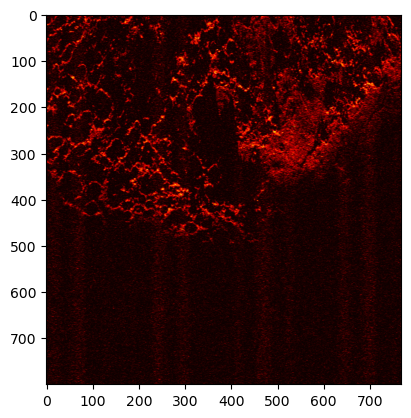

In [226]:
plt.figure()
plt.imshow(frame_sim_noise_polar, cmap = 'hot')
plt.show()
# ax[0].set_title('simulated fls frame - polar')

Text(0.5, 1.0, 'real fls frame')

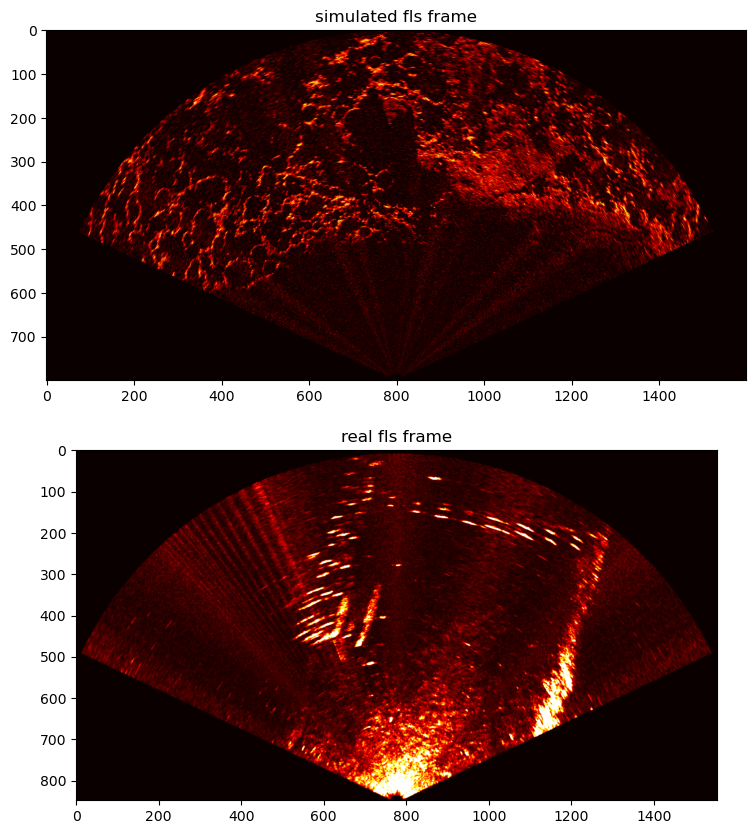

In [227]:
fig, ax = plt.subplots(2, 1, figsize = (20, 10))


# ax[0].imshow(frame_sim_noise_polar, cmap = 'hot')
# ax[0].set_title('simulated fls frame - polar')

ax[0].imshow(frame_sim_noise, cmap = 'hot')
ax[0].set_title('simulated fls frame')

ax[1].imshow(frame_real, cmap = 'hot')
ax[1].set_title('real fls frame')

